# Dosage Compensation Analysis
September 16, 2024

**Goal:**
Analyze the gene expression for genes whose expression correlates highly with replication. Identify these genes and study literature onto what may be happening for these genes.

**Procedure:**
1. Compute the correlation between gene expression and replication count.
2. Identify genes with the highest correlation.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.config import read_yl_vst_data_rep

gene_expression_1 = read_yl_vst_data_rep(1)


In [3]:
from src.copy_correction_reanalysis import CopyCorrectionAnalysis

copy_analysis = CopyCorrectionAnalysis()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:03.741
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:06.574


In [4]:
copy_analysis.set_replicate(1)

In [5]:
from src.CopyNumberCorrection import get_bin_for_position
from src.geneset import get_deconvolved_geneset

genes = get_deconvolved_geneset()


In [6]:
from scipy.stats import pearsonr

def compute_corr(gene):
    start_indices = copy_analysis.chrom_replication_profile.loc[gene.chr].index
    repl_bin, start_ind = get_bin_for_position(gene.TSS, start_indices)
    repl_bin, start_ind
    expression_curve = gene_expression_1.loc[gene.name]
    repl_curve = copy_analysis.chrom_bin_curves.loc[gene.chr].loc[start_ind]
    pearson, pval = pearsonr(expression_curve, repl_curve)
    return pearson, pval

gene_repl_tx_corr = genes[[]].copy()
for orf_name, gene in genes.iterrows():
    pearson, pval = compute_corr(gene)
    gene_repl_tx_corr.loc[orf_name, 'pearson'] = pearson
    gene_repl_tx_corr.loc[orf_name, 'pval'] = pval


/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


Genes with maximal expression for quantile: 0.5
is set at 10.58 expression level. 2789 genes meet this criteria
Selected 279 genes in the top 80% with quantile value greater than 1.15


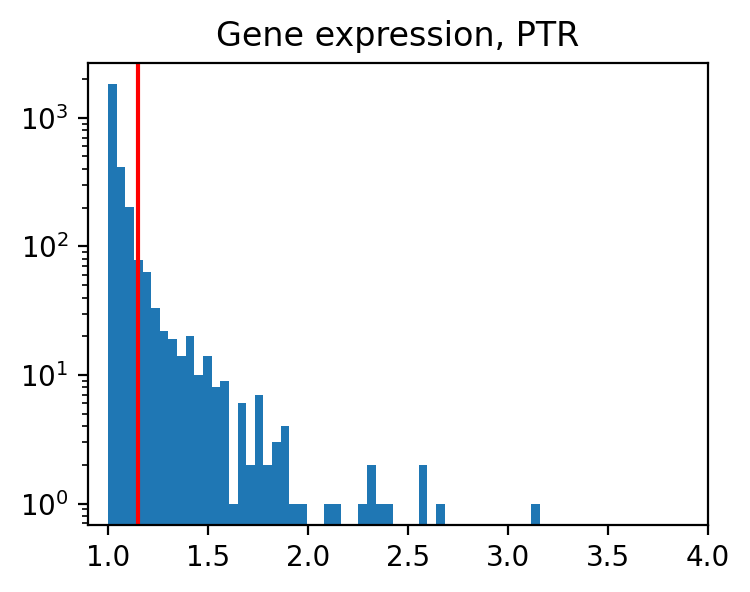

In [7]:
from src.gene_clustering import GeneClustering
outdir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/'
gene_clustering = GeneClustering(outdir)
gene_clustering.set_max_expression_threshold()
gene_clustering.set_threshold_ptr(0.9)

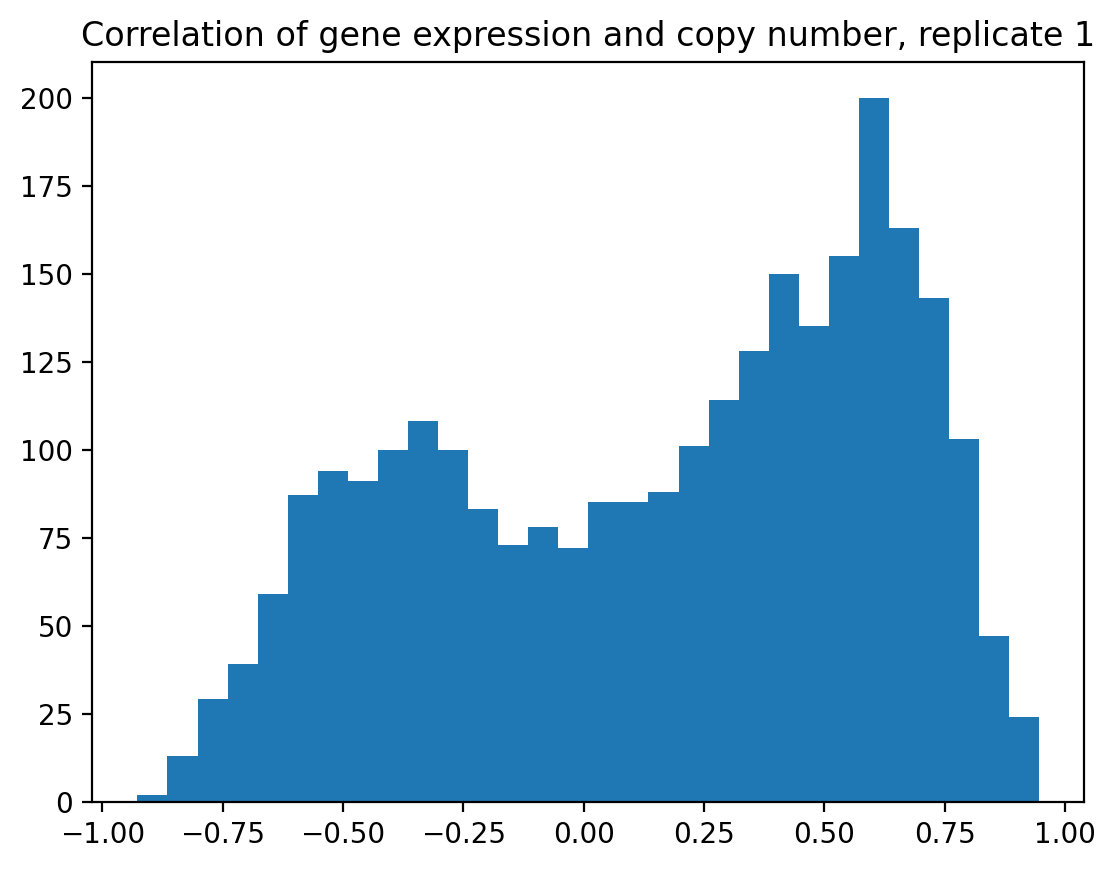

In [8]:
gene_repl_tx_corr_nona = gene_repl_tx_corr.loc[gene_clustering.high_max_expression_genes].dropna()
gene_repl_tx_corr_rank = gene_repl_tx_corr_nona.join(genes[['gene']], 
    how='inner').sort_values('pearson', ascending=False)
gene_repl_tx_corr_rank['rank'] = np.arange(1, len(gene_repl_tx_corr_rank)+1)

plt.hist(gene_repl_tx_corr_rank.pearson, bins=30)
plt.title("Correlation of gene expression and copy number, replicate 1")

# Bimodal, set of genes that correlate well and don't correlate with replication
# Select these genes with correlation patterns with respect to copy correction and
# plot chromatin
hi_cor_with_tx_genes = gene_repl_tx_corr_rank.head(200).index.values
lo_cor_with_tx_genes = gene_repl_tx_corr_rank.tail(200).index.values
lo_abs_correlation_genes = np.abs(gene_repl_tx_corr_rank.pearson).sort_values().head(200).index.values

Shape of the loaded F: (178, 2093)
(178, 2093)
1/200 - 00:00:00.034
Shape of the loaded F: (178, 2093)
(178, 2093)
1/200 - 00:00:00.035
Shape of the loaded F: (178, 2093)
(178, 2093)
1/200 - 00:00:00.031
Shape of the loaded F: (178, 2093)
(178, 2093)
1/200 - 00:00:00.040
Shape of the loaded F: (178, 2093)
(178, 2093)
1/200 - 00:00:00.034
Shape of the loaded F: (178, 2093)
(178, 2093)
1/200 - 00:00:00.033


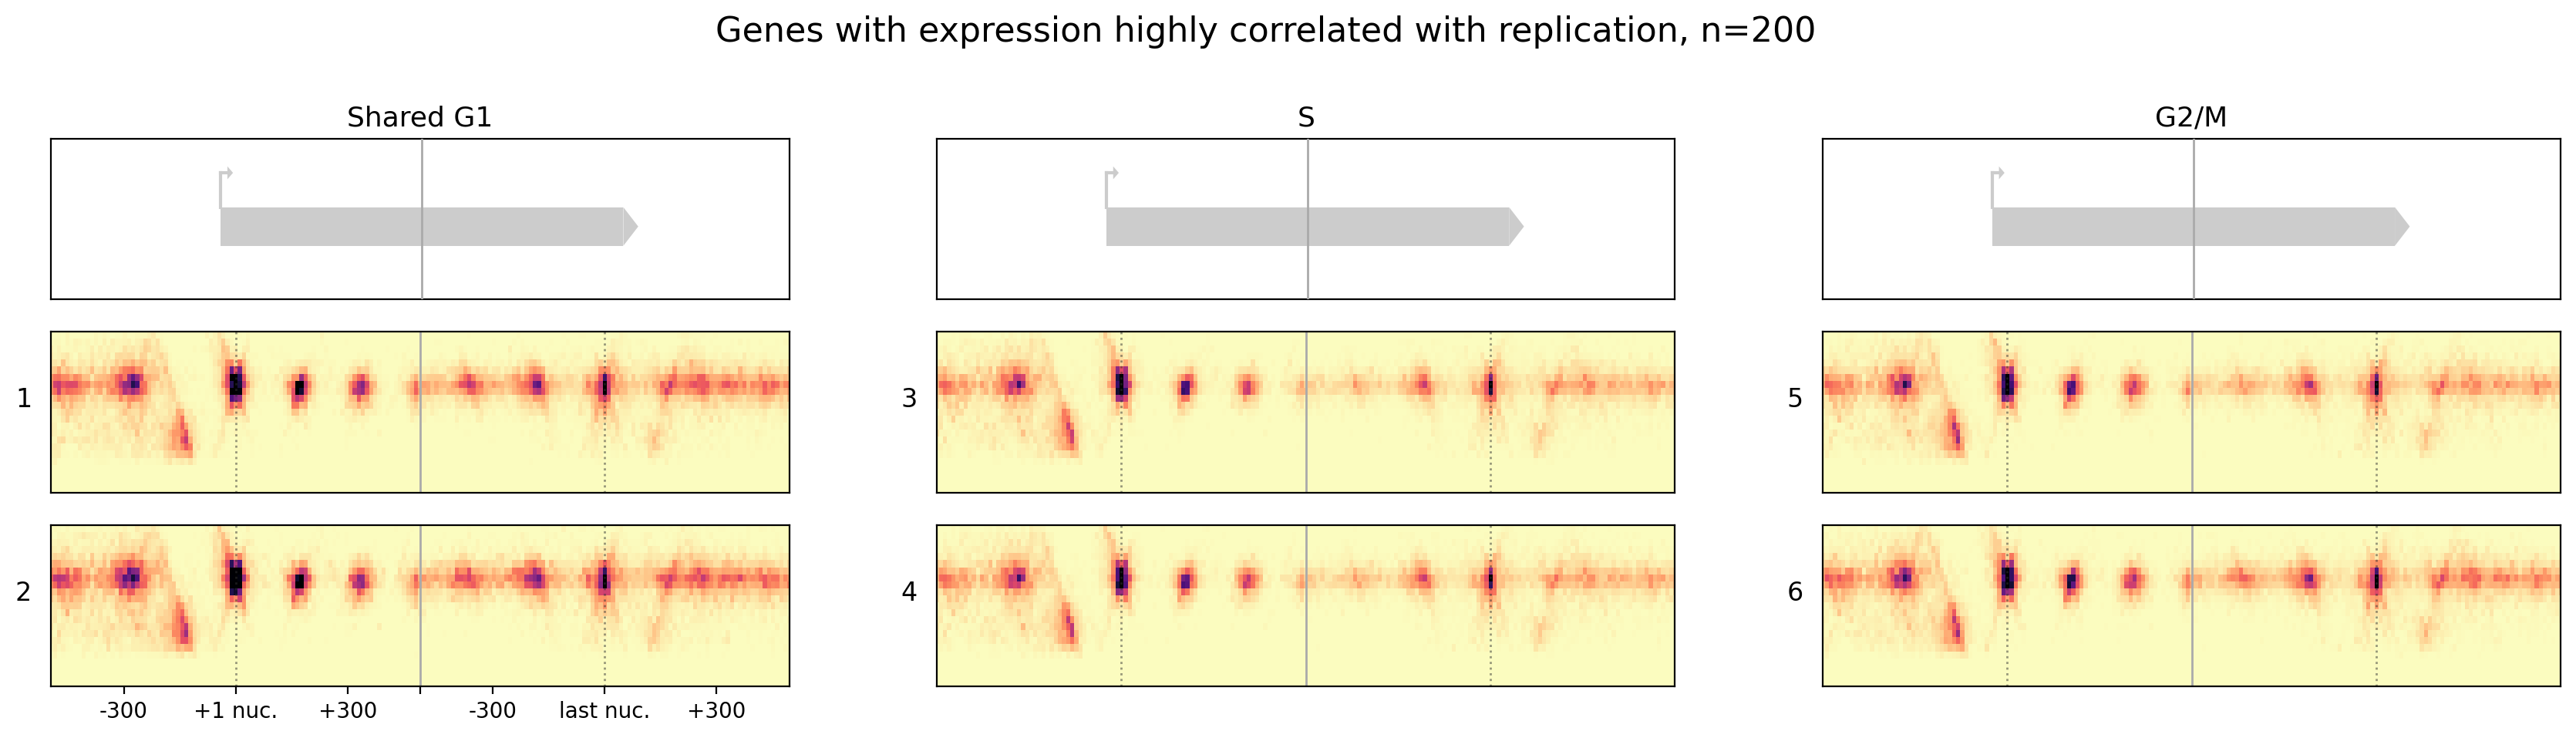

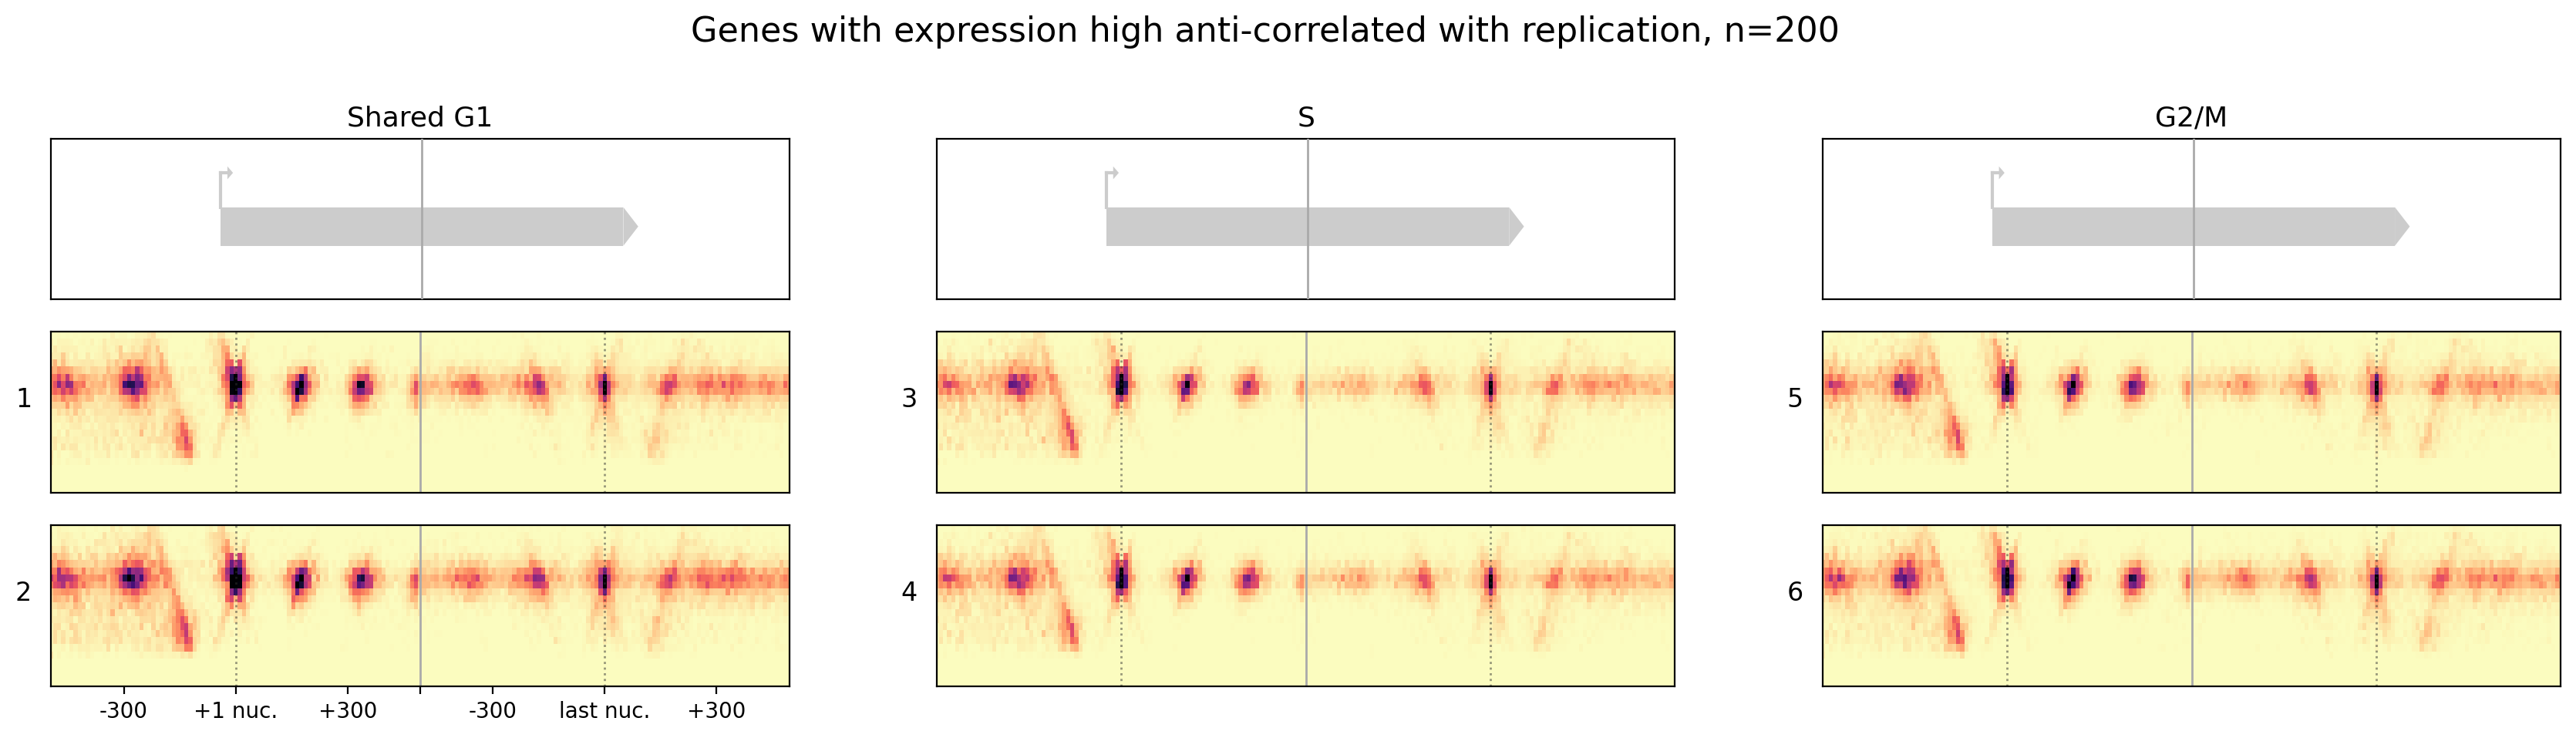

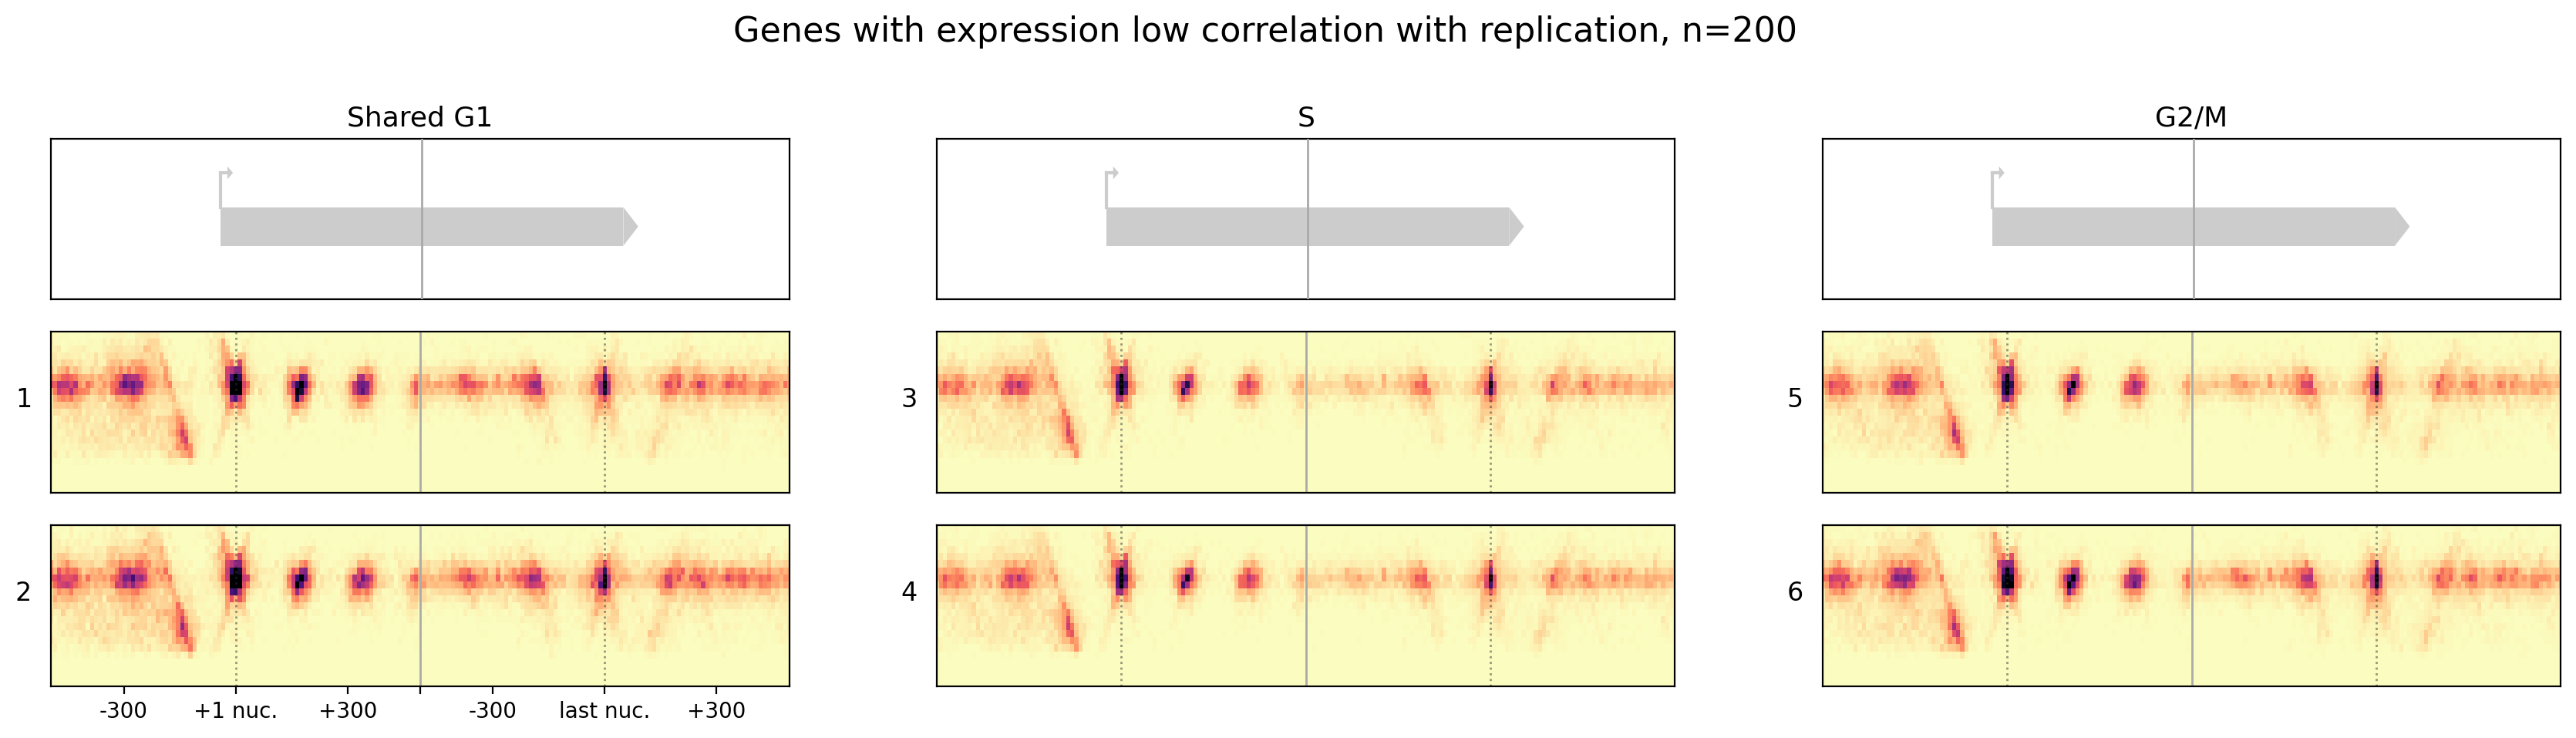

In [9]:
from src.gene_clustering import load_chromatin_from_dir

TSS_chromatin_dir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/chromatin/'
PAS_chromatin_dir = 'output/deconvolve_sharedg1_g0066_11x11_PAS_2024_09_12/chromatin/'

orf_names = hi_cor_with_tx_genes
TSS_imgs = load_chromatin_from_dir(TSS_chromatin_dir, orf_names)
PAS_imgs = load_chromatin_from_dir(PAS_chromatin_dir, orf_names)
from src.gene_clustering import plot_chromatin
fig = plot_chromatin(TSS_imgs.mean(axis=0), PAS_imgs.mean(axis=0), 
    title=f"Genes with expression highly correlated with replication, n={len(TSS_imgs)}")

orf_names = lo_cor_with_tx_genes
TSS_imgs = load_chromatin_from_dir(TSS_chromatin_dir, orf_names)
PAS_imgs = load_chromatin_from_dir(PAS_chromatin_dir, orf_names)
fig = plot_chromatin(TSS_imgs.mean(axis=0), PAS_imgs.mean(axis=0), 
    title=f"Genes with expression high anti-correlated with replication, n={len(TSS_imgs)}")

orf_names = lo_abs_correlation_genes
TSS_imgs = load_chromatin_from_dir(TSS_chromatin_dir, orf_names)
PAS_imgs = load_chromatin_from_dir(PAS_chromatin_dir, orf_names)
fig = plot_chromatin(TSS_imgs.mean(axis=0), PAS_imgs.mean(axis=0), 
    title=f"Genes with expression low correlation with replication, n={len(TSS_imgs)}")


In [10]:
histone_mods_df = pd.read_csv('/Users/trung/Downloads/molcel_5341_mmc4',
                              index_col=0, skiprows=[1])

In [11]:
h3k56_cols = histone_mods_df.columns.str.startswith("H3K56")
h3k56_cols = histone_mods_df.columns[h3k56_cols]
h3k56_df = histone_mods_df[h3k56_cols]
h3k56_sorted_df = h3k56_df.loc[h3k56_df.mean(axis=1).sort_values().index]

# We'll say if the h3k56 value is greater than 1, it is acetylated
h3k56_modified = h3k56_df[h3k56_df.mean(axis=1) > 1]
h3k56_modified

,H3K56ac,H3K56ac.1,H3K56ac.2,H3K56ac.3,H3K56ac.4,H3K56ac.5
355,1.29,0.99,1.19,1.08,1.14,1.01
356,0.99,1.04,1.02,0.83,0.91,1.29
552,1.06,0.87,1.19,1.03,1.11,0.91
559,1.14,0.90,1.20,1.14,0.99,0.82
643,1.32,0.97,1.32,1.12,0.89,0.67
...,...,...,...,...,...,...
65953,1.79,1.41,1.56,1.30,1.08,1.20
66050,1.25,1.03,1.18,1.07,1.17,1.02
66051,1.20,1.03,1.09,0.92,1.24,0.92
66137,1.18,1.35,1.17,1.03,0.95,0.96


In [12]:
histone_mod_nuc_db = pd.read_csv('/Users/trung/Downloads/mmc3.csv')
histone_mod_nuc_db = histone_mod_nuc_db.set_index('nuc_id')
histone_mod_nuc_db.sort_values(['chr', 'center'])

orfs_w_h3k56ac = h3k56_modified[[]].join(histone_mod_nuc_db, how='inner').acc.dropna().values
print(f"Number of genes with H3K56 acetylation: {len(orfs_w_h3k56ac)}")

Number of genes with H3K56 acetylation: 900


In [13]:
def compute_venn(a, b):
    a = set(a)
    b = set(b)
    union = a.union(b)

    return union - b, a.intersection(b), union - a

In [14]:
_, lo_abs_correlation_genes_w_h3k56ac, _ = compute_venn(orfs_w_h3k56ac, lo_abs_correlation_genes)
_, lo_correlation_genes_w_h3k56ac, _ = compute_venn(orfs_w_h3k56ac, lo_cor_with_tx_genes)
_, hi_correlation_genes_w_h3k56ac, _ = compute_venn(orfs_w_h3k56ac, hi_cor_with_tx_genes)

print("Counts of genes with H3K56 acetylation:")
print(f"# with low absolute correlation (close to 0): {len(lo_abs_correlation_genes_w_h3k56ac)}")
print(f"# with anticorrelation (greatest negative): {len(lo_correlation_genes_w_h3k56ac)}")
print(f"# with highest correlation (greatest positive): {len(hi_correlation_genes_w_h3k56ac)}")

Counts of genes with H3K56 acetylation:
# with low absolute correlation (close to 0): 30
# with anticorrelation (greatest negative): 31
# with highest correlation (greatest positive): 18


Shape of the loaded F: (178, 2093)
(178, 2093)
1/30 - 00:00:00.018
Shape of the loaded F: (178, 2093)
(178, 2093)
1/30 - 00:00:00.018


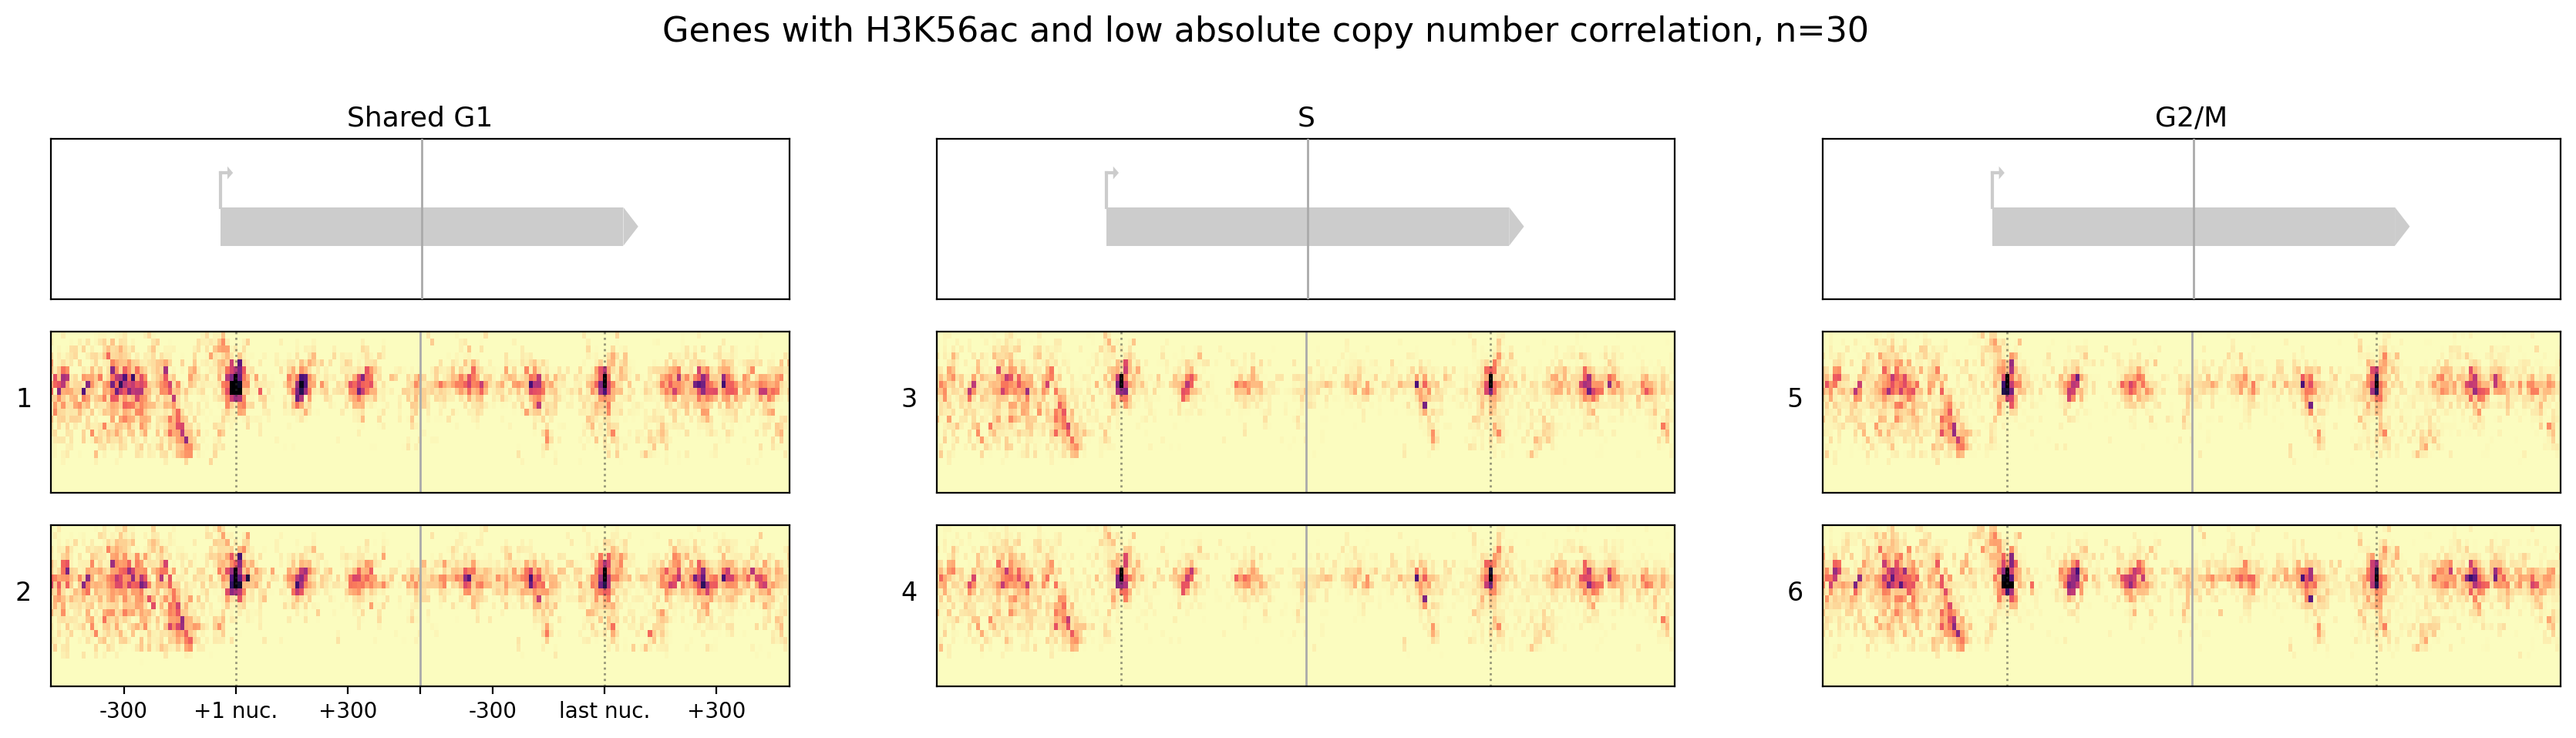

In [15]:
orf_names = list(lo_abs_correlation_genes_w_h3k56ac)
TSS_imgs = load_chromatin_from_dir(TSS_chromatin_dir, orf_names)
PAS_imgs = load_chromatin_from_dir(PAS_chromatin_dir, orf_names)
fig = plot_chromatin(TSS_imgs.mean(axis=0), PAS_imgs.mean(axis=0), 
    title=f"Genes with H3K56ac and low absolute copy number correlation, n={len(TSS_imgs)}")

Shape of the loaded F: (178, 2093)
(178, 2093)
1/31 - 00:00:00.015
Shape of the loaded F: (178, 2093)
(178, 2093)
1/31 - 00:00:00.015


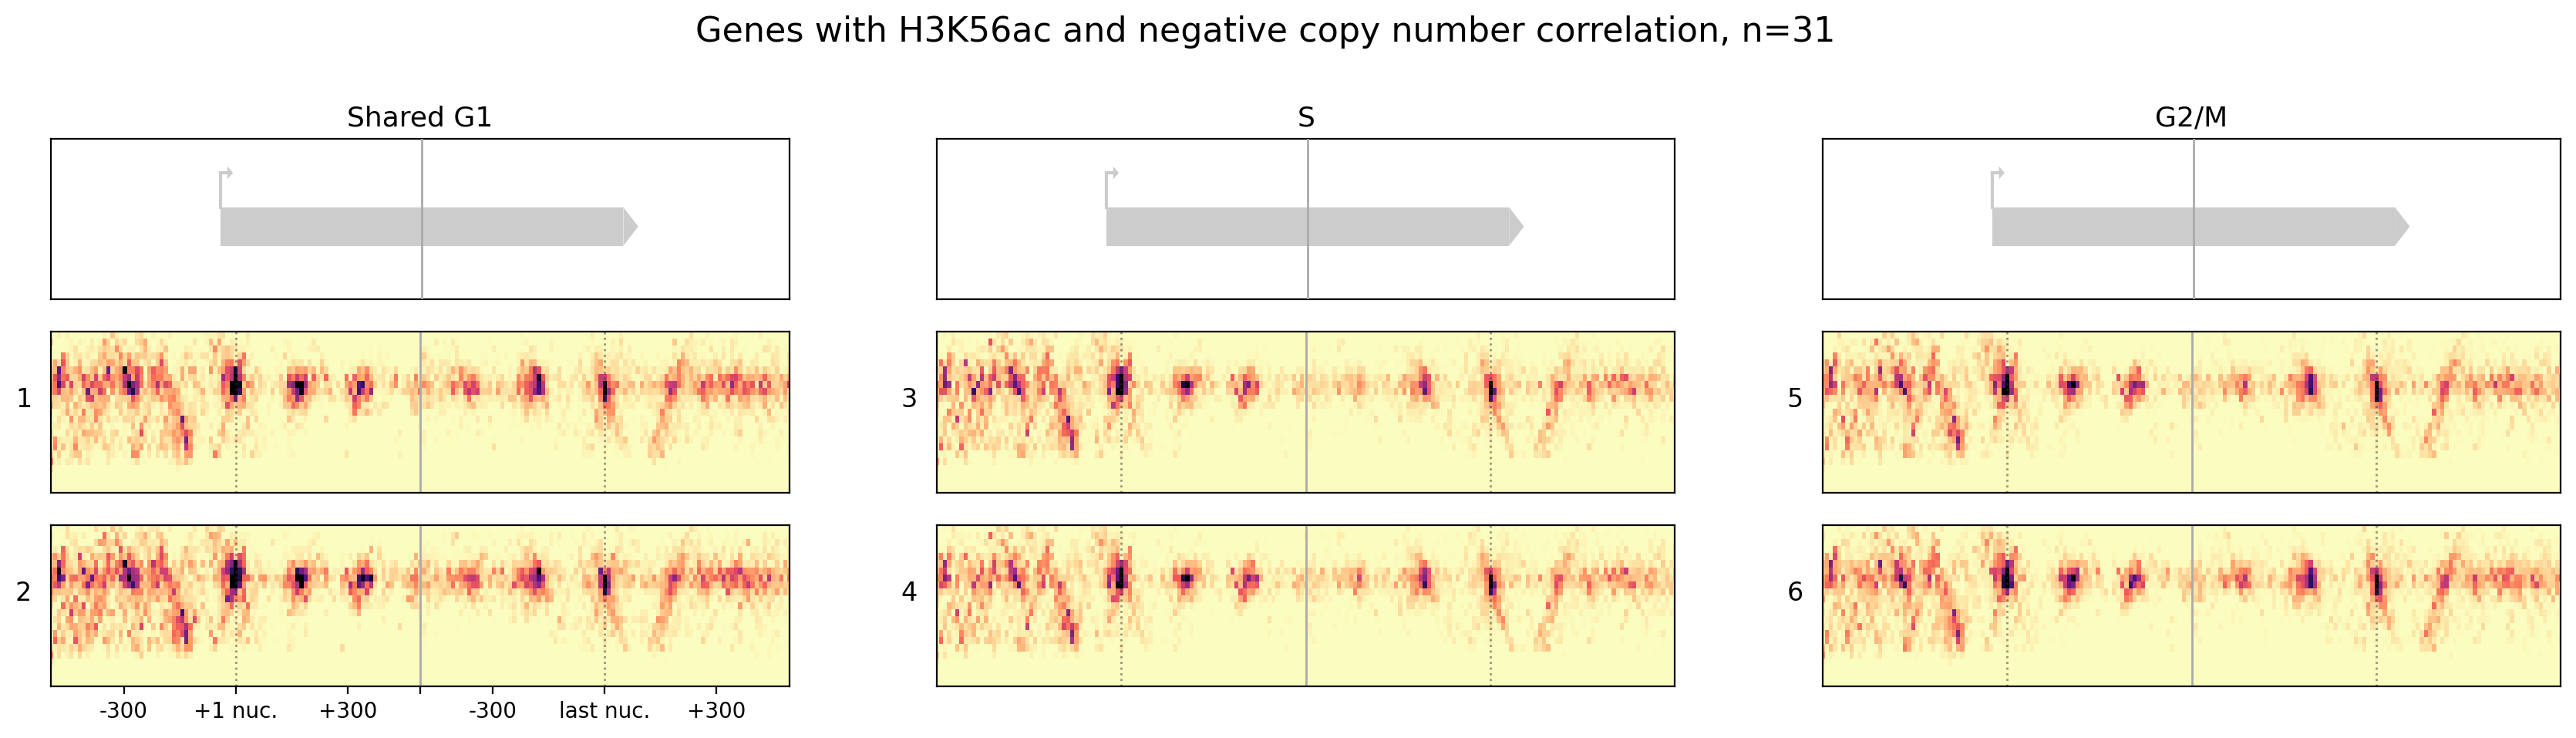

In [16]:
orf_names = list(lo_correlation_genes_w_h3k56ac)
TSS_imgs = load_chromatin_from_dir(TSS_chromatin_dir, orf_names)
PAS_imgs = load_chromatin_from_dir(PAS_chromatin_dir, orf_names)
fig = plot_chromatin(TSS_imgs.mean(axis=0), PAS_imgs.mean(axis=0), 
    title=f"Genes with H3K56ac and negative copy number correlation, n={len(TSS_imgs)}")

Shape of the loaded F: (178, 2093)
(178, 2093)
1/18 - 00:00:00.009
Shape of the loaded F: (178, 2093)
(178, 2093)
1/18 - 00:00:00.009


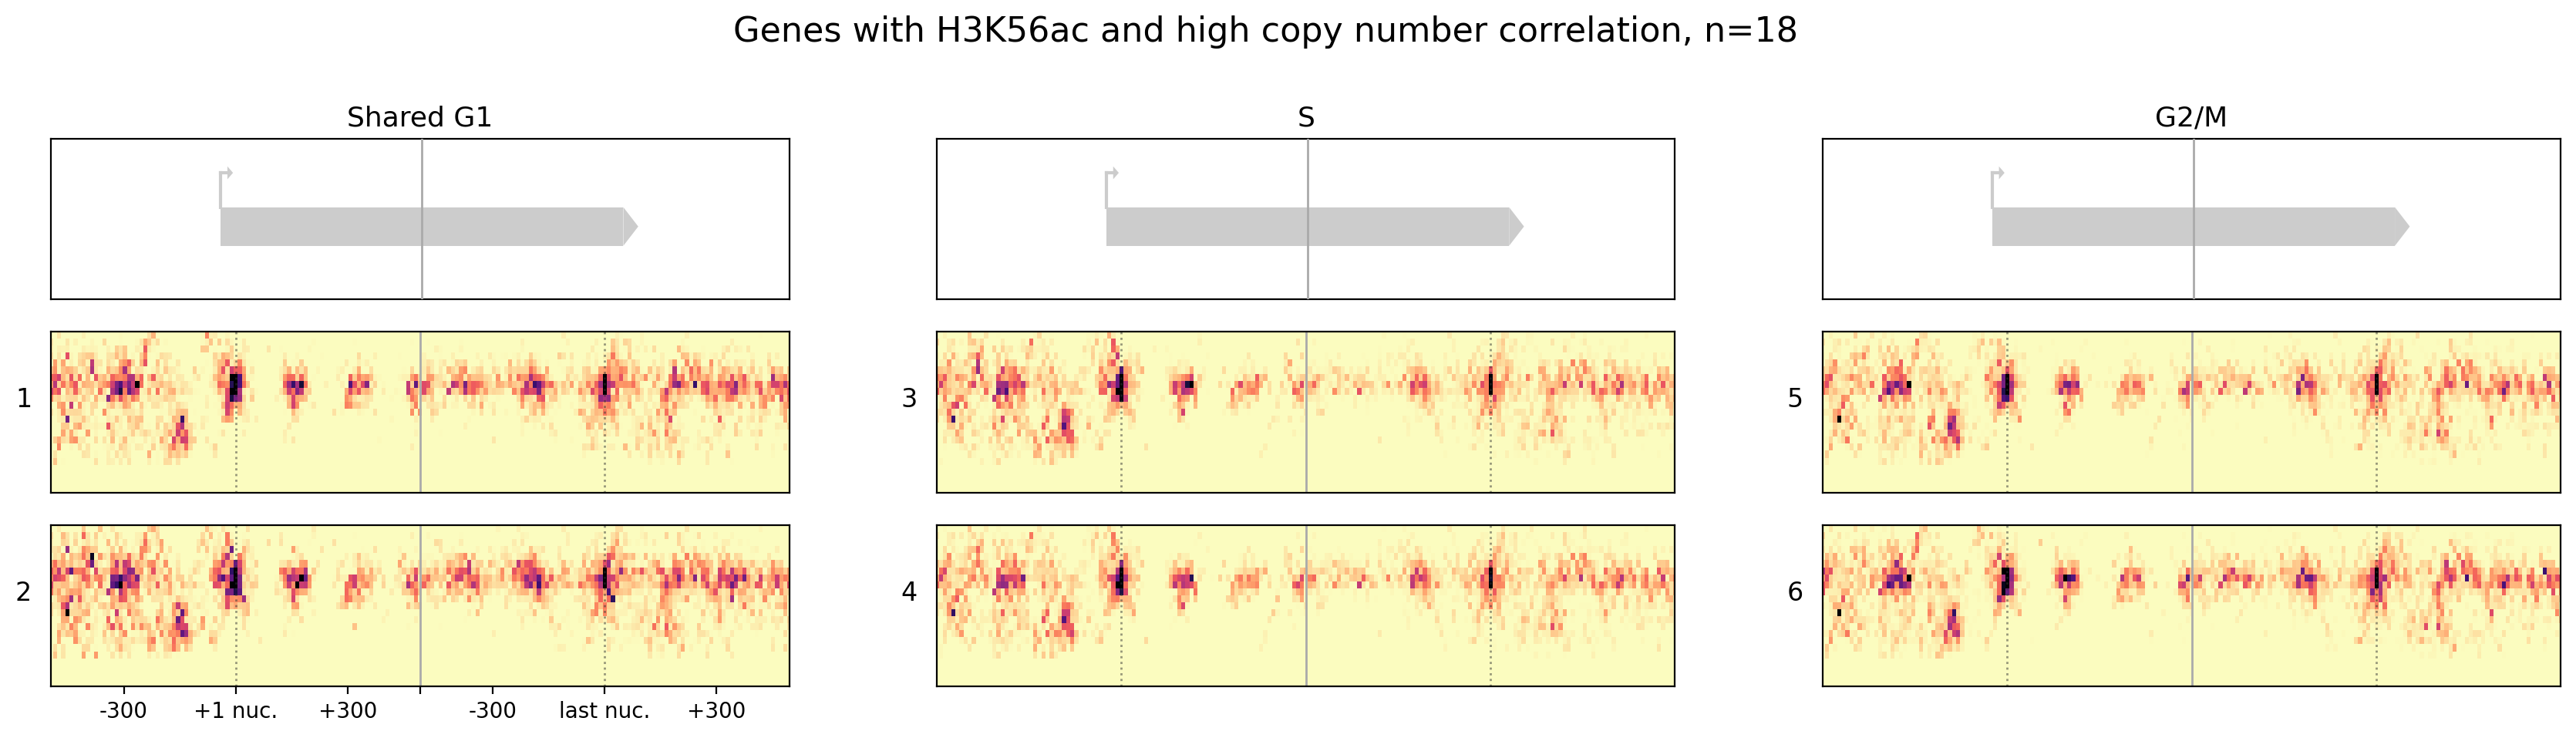

In [17]:
orf_names = list(hi_correlation_genes_w_h3k56ac)
TSS_imgs = load_chromatin_from_dir(TSS_chromatin_dir, orf_names)
PAS_imgs = load_chromatin_from_dir(PAS_chromatin_dir, orf_names)
fig = plot_chromatin(TSS_imgs.mean(axis=0), PAS_imgs.mean(axis=0), 
    title=f"Genes with H3K56ac and high copy number correlation, n={len(TSS_imgs)}")

In [18]:
# Now look at genes with high and low H3K56 acetylation, regardless of the copy correction
# correlation
h3k56_sorted_w_orfs = h3k56_sorted_df.join(histone_mod_nuc_db[['acc']]).dropna()
h3k56_lo_ac_orfs = h3k56_sorted_w_orfs.head(500).acc.values
h3k56_hi_ac_orfs = h3k56_sorted_w_orfs.tail(500).acc.values

In [73]:
geneset_h3k56_sorted_w_orfs = h3k56_sorted_w_orfs.set_index('acc').join(genes[[]], how='inner')
geneset_h3k56_sorted_w_orfs = geneset_h3k56_sorted_w_orfs.sort_values('mean_H3K56_acetylation')

In [74]:
geneset_h3k56_sorted_w_orfs

,gene,center,chr,mean_H3K56_acetylation
acc,,,,
YAL001C,TFC3,151535,1,-2.421667
YPR001W,CIT3,556024,16,-2.360000
YFR001W,LOC1,148578,6,-2.261667
YGL001C,ERG26,496967,7,-2.165000
YJR001W,AVT1,436356,10,-2.070000
...,...,...,...,...
YBR010W,HHT1,256413,2,1.775000
YDR225W,HTA1,915440,4,1.776667
YGL148W,ARO2,226088,7,1.870000


In [78]:
h3k56_lo_ac_orfs_intersection = geneset_h3k56_sorted_w_orfs.head(200).index.values
h3k56_hi_ac_orfs_intersection = geneset_h3k56_sorted_w_orfs.tail(200).index.values


In [79]:
len(h3k56_lo_ac_orfs_intersection), len(h3k56_hi_ac_orfs_intersection)

(200, 200)

Shape of the loaded F: (178, 2093)
(178, 2093)
1/200 - 00:00:00.051
Shape of the loaded F: (178, 2093)
(178, 2093)
1/200 - 00:00:00.030


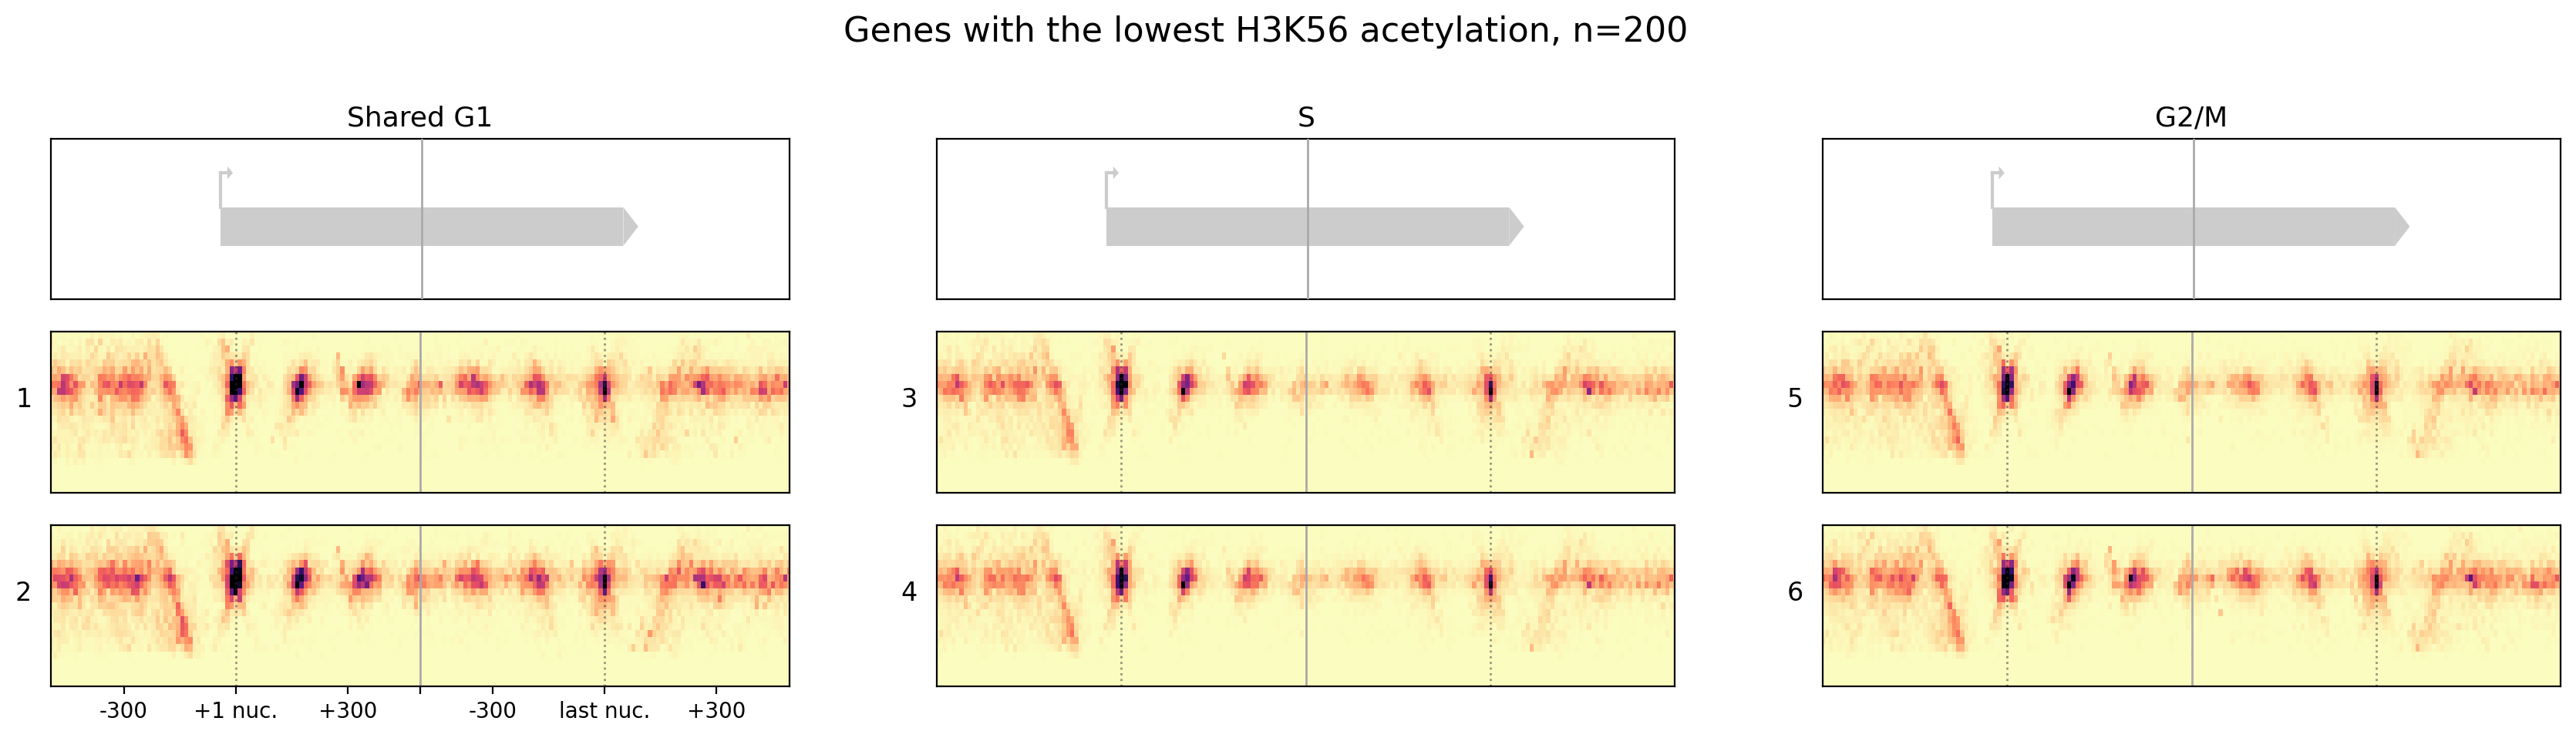

In [80]:
orf_names = list(h3k56_lo_ac_orfs_intersection)
TSS_imgs = load_chromatin_from_dir(TSS_chromatin_dir, orf_names)
PAS_imgs = load_chromatin_from_dir(PAS_chromatin_dir, orf_names)
fig = plot_chromatin(TSS_imgs.mean(axis=0), PAS_imgs.mean(axis=0), 
    title=f"Genes with the lowest H3K56 acetylation, n={len(orf_names)}")

Shape of the loaded F: (178, 2093)
(178, 2093)
1/200 - 00:00:00.042
Shape of the loaded F: (178, 2093)
(178, 2093)
1/200 - 00:00:00.036


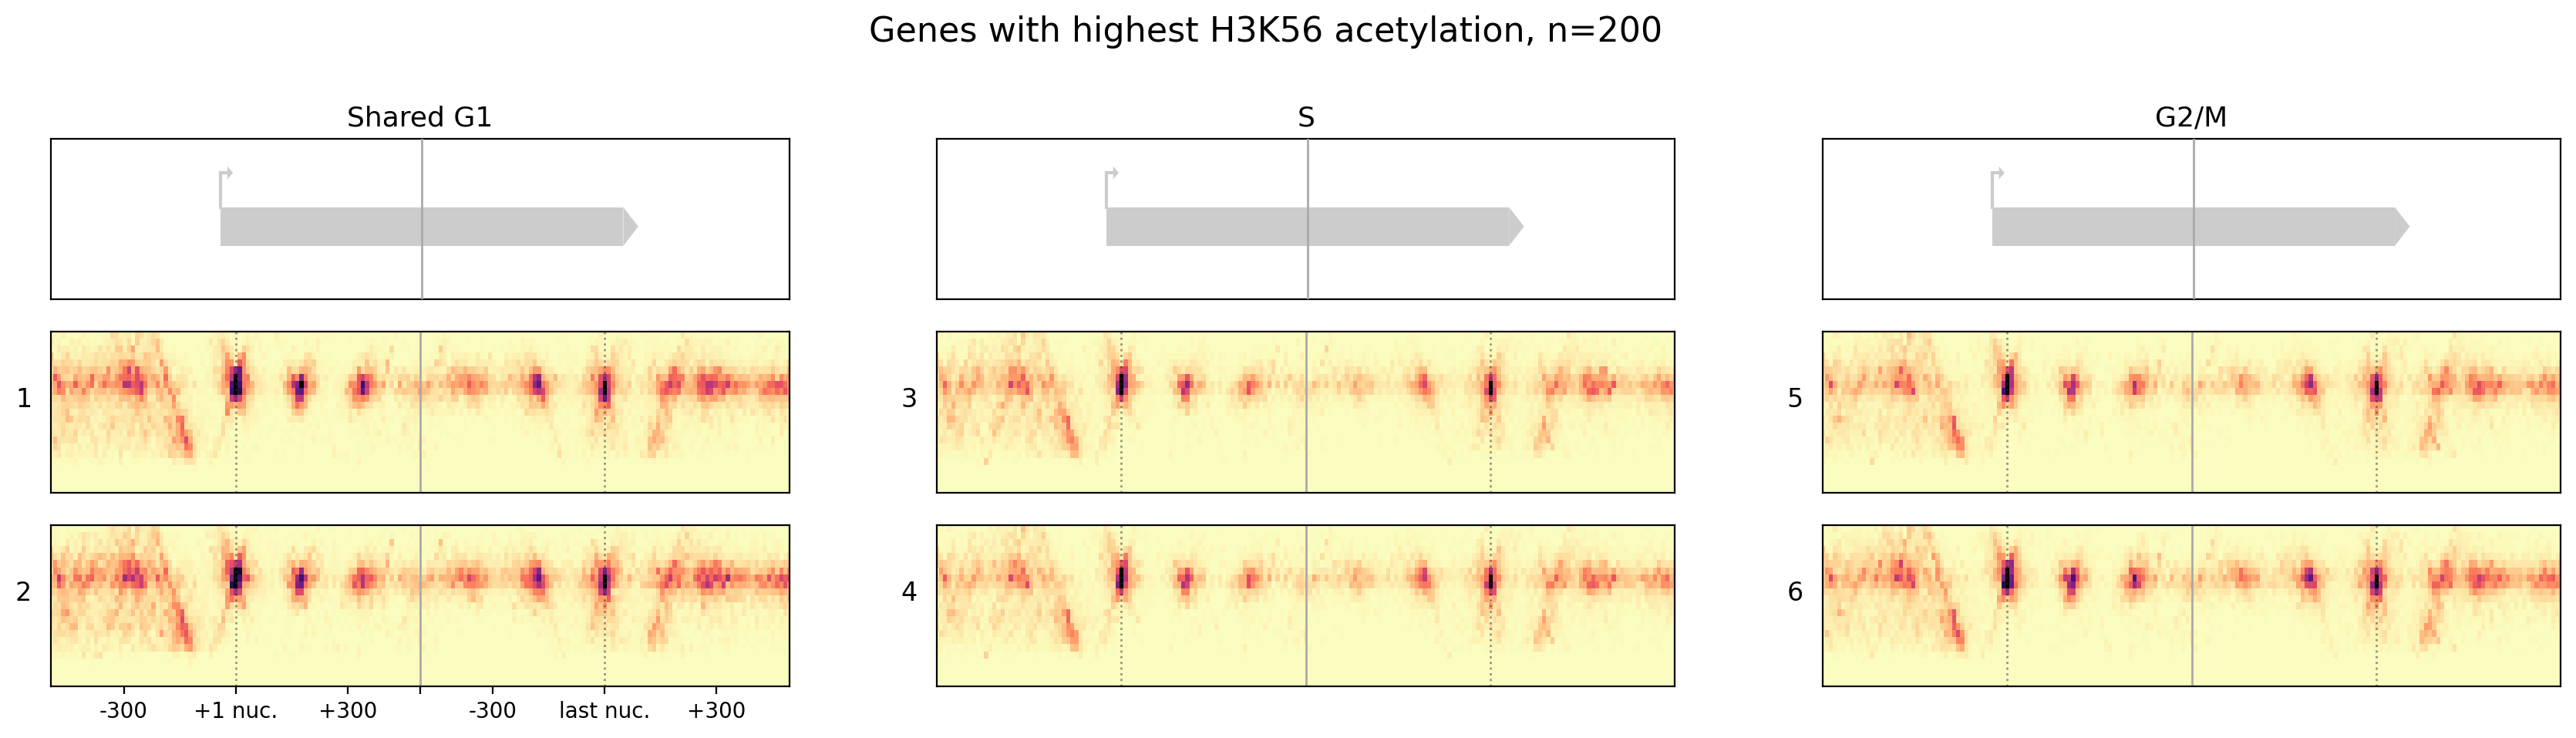

In [81]:
orf_names = list(h3k56_hi_ac_orfs_intersection)
TSS_imgs = load_chromatin_from_dir(TSS_chromatin_dir, orf_names)
PAS_imgs = load_chromatin_from_dir(PAS_chromatin_dir, orf_names)
fig = plot_chromatin(TSS_imgs.mean(axis=0), PAS_imgs.mean(axis=0), 
    title=f"Genes with highest H3K56 acetylation, n={len(orf_names)}")


In [23]:
mean_acetylation = h3k56_sorted_df.mean(axis=1)

In [24]:
h3k56_sorted_w_orfs = h3k56_sorted_df[[]].join(histone_mod_nuc_db[['gene', 'acc', 'center', 'chr']]).dropna()
h3k56_sorted_w_orfs['mean_H3K56_acetylation'] = mean_acetylation

Text(0.5, 1.0, 'H3K56 modifications mean')

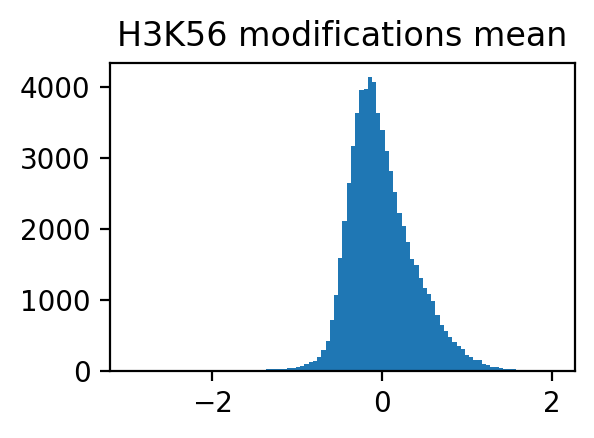

In [25]:
plt.figure(figsize=(3, 2))
plt.hist(mean_acetylation, bins=100)
plt.title("H3K56 modifications mean")


In [26]:
# Load the raw data in aggregate for the highest and lowest acetylated nucleosomes
histone_mod_w_acetylation_db = histone_mod_nuc_db.loc[mean_acetylation.index]
histone_mod_w_acetylation_db['mean_H3K56ac'] = mean_acetylation

lowest_acetylation = histone_mod_w_acetylation_db.head(500)
highest_acetylation = histone_mod_w_acetylation_db.tail(500)

lowest_acetylation = lowest_acetylation.sort_values(['chr', 'center'])
highest_acetylation = highest_acetylation.sort_values(['chr', 'center'])

In [27]:
from src.global_config import GlobalConstants

def create_histogram_for_locus(nuc_reads, x_bins, y_bins):
    timepoints = GlobalConstants.CHROM_WT1_TIMEPOINTS
    n = len(timepoints)
    nuc_histogram = np.zeros((n, len(y_bins)-1, len(x_bins)-1))

    for i in range(n):
        sample = timepoints[i]
        sample_reads = nuc_reads[nuc_reads['sample'] == sample]
        hist, x_edges, y_edges = np.histogram2d(sample_reads['mid'], 
            sample_reads['length'], bins=[x_bins, y_bins])
        sample_hist = hist.T
        nuc_histogram[i] = sample_hist
    return nuc_histogram


In [28]:
from src.chromatin_model import read_chromosome_mnase_reads

def create_histogram_of_reads(lowest_acetylation):

    span = 500
    replicate = 1
    
    x_bins = np.arange(-span, span+1)
    y_bins = np.arange(0, 252)
    y_len = len(y_bins)-1
    x_len = len(x_bins)-1

    num_sites = len(lowest_acetylation)
    timepoints = GlobalConstants.CHROM_WT1_TIMEPOINTS
    n = len(timepoints)
    all_nucs_histogram = np.zeros((num_sites, n, y_len, x_len))

    nuc_num = 0
    for chrom in range(1, 17):
        print(chrom, end=", ")
        chr_reads = read_chromosome_mnase_reads(replicate, chrom)
        chr_acetylation = lowest_acetylation[lowest_acetylation.chr == chrom]

        # Skip chromosome 12 for now
        if chrom == 12: continue

        for _, nuc_row in chr_acetylation.iterrows():
            center = nuc_row.center
            nuc_reads = chr_reads[(chr_reads.mid >= center-span) & 
                (chr_reads.mid < center+span)].copy()
            nuc_reads.mid = nuc_reads.mid - center
            nuc_hist = create_histogram_for_locus(nuc_reads, x_bins, y_bins)

            all_nucs_histogram[nuc_num] = nuc_hist
            nuc_num += 1
        
    return all_nucs_histogram


In [29]:
low_acetylation_hist = create_histogram_of_reads(lowest_acetylation)

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 

In [30]:
high_nucs_histogram = create_histogram_of_reads(highest_acetylation)

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 

In [58]:
from src.global_config import GlobalConstants

def plot_im_of_nucs_heatmap(nuc_histogram, vmax=0.1):
    timepoints = GlobalConstants.CHROM_WT1_TIMEPOINTS
    n = len(timepoints)
    fig, axs = plt.subplots(n//2, 2, figsize=(6, 6))
    axs = np.array(axs).T.flatten()

    for i in range(n):
        ax = axs[i]
        ax.imshow(nuc_histogram[i], vmax=vmax, cmap='magma_r', origin='lower', aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])

    plt.subplots_adjust(hspace=0, wspace=0)


In [32]:
lowest_aggregete_hist = low_acetylation_hist.mean(axis=0)

In [33]:
highest_aggregete_hist = high_nucs_histogram.mean(axis=0)

In [39]:
# Normalize the histogram by scaling, this should enforce all samples to be overall
# the same number of reads
len_scaling = pd.read_csv('datasets/computed_mnase/rep1_len_scaling.csv').set_index("Unnamed: 0")


In [43]:
len_scaling.shape

(251, 16)

In [50]:

def normalize_len_scale(lowest_aggregete_hist, len_scaling):
    normalized_lowest_aggregete_hist = lowest_aggregete_hist.copy()
    
    for i in range(len_scaling.shape[1]):
        normalized_lowest_aggregete_hist[i] = lowest_aggregete_hist[i] *\
            len_scaling[len_scaling.columns[i]].values.reshape((-1, 1))

    return normalized_lowest_aggregete_hist

In [51]:
normalized_lowest_aggregete_hist = normalize_len_scale(lowest_aggregete_hist, len_scaling)
normalized_highest_aggregete_hist = normalize_len_scale(highest_aggregete_hist, len_scaling)


Text(0.5, 0.98, 'Lowest H3K56 acetylation nucleosomes\nn=500, Replicate 1')

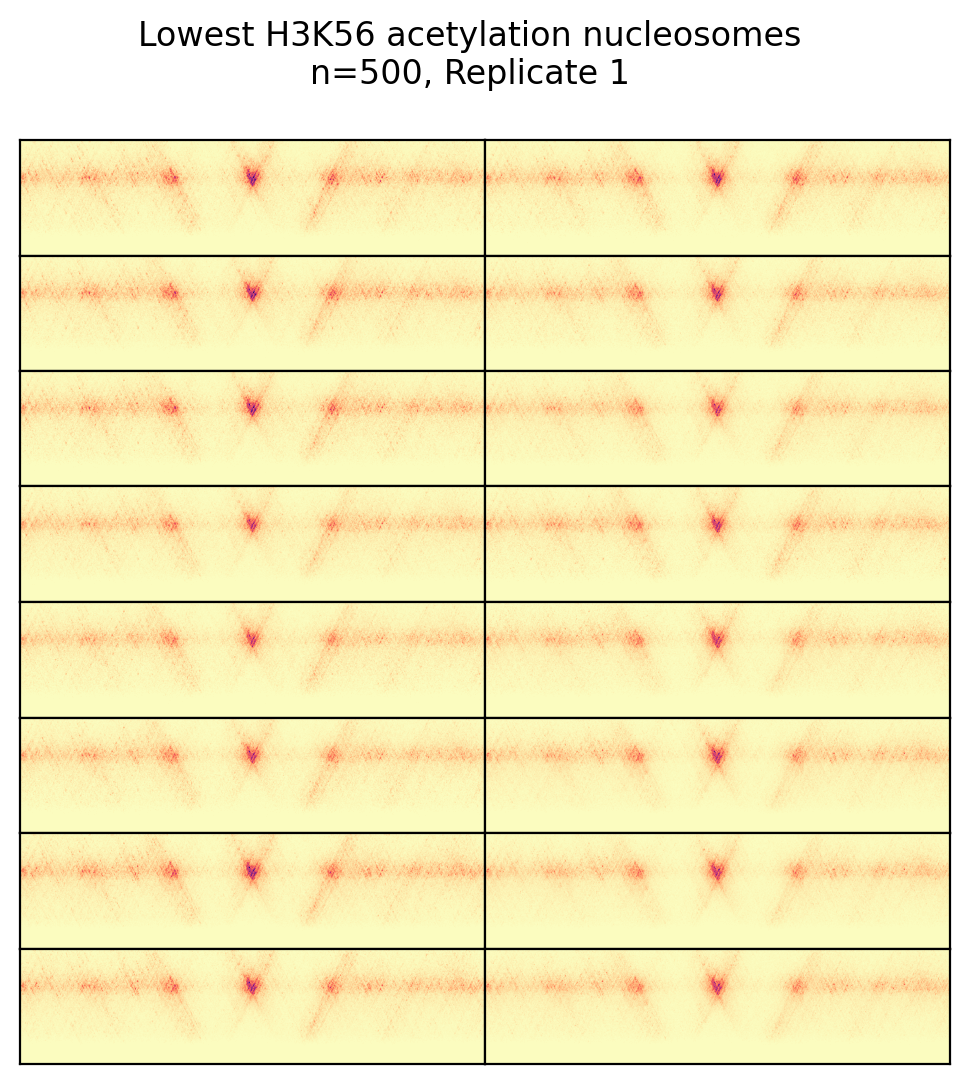

In [82]:
plot_im_of_nucs_heatmap(normalized_lowest_aggregete_hist)
plt.suptitle(f"Lowest H3K56 acetylation nucleosomes\nn={len(low_acetylation_hist)}, Replicate 1")

Text(0.5, 0.98, 'Highest H3K56 acetylation nucleosomes\nn=500, Replicate 1')

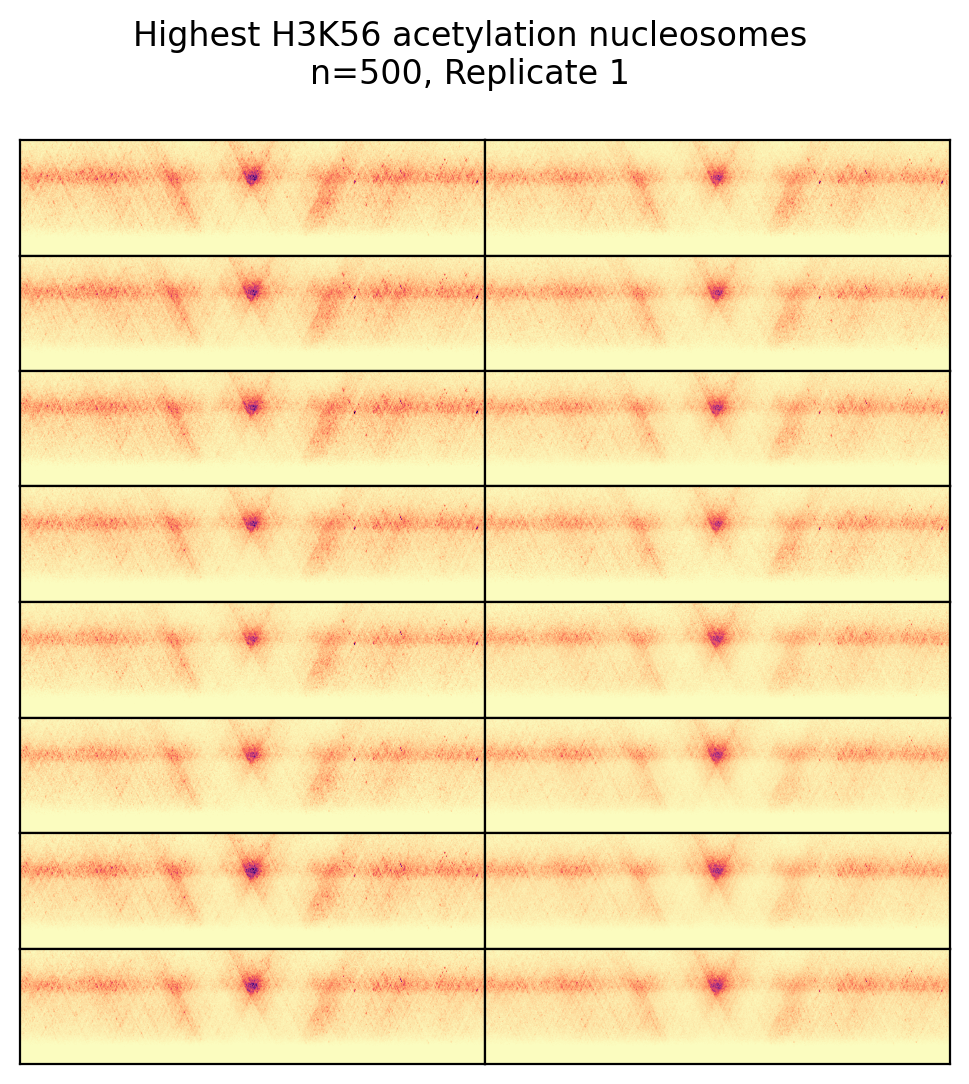

In [83]:
plot_im_of_nucs_heatmap(normalized_highest_aggregete_hist)
plt.suptitle(f"Highest H3K56 acetylation nucleosomes\nn={len(low_acetylation_hist)}, Replicate 1")